In [70]:
import tensorflow as tf
from tensorflow import keras

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
test_scaled = test_input / 255.0

In [71]:
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

print('훈련 데이터 :', train_scaled.shape, train_target.shape)
print('검증 데이터 :', val_scaled.shape, val_target.shape)
print("테스트 데이터 :", test_scaled.shape, test_target.shape)

훈련 데이터 : (48000, 28, 28) (48000,)
검증 데이터 : (12000, 28, 28) (12000,)
테스트 데이터 : (10000, 28, 28) (10000,)


In [72]:
def create_model_for_categorical():
    return keras.Sequential([
        keras.layers.Flatten(input_shape=(28, 28)),
        keras.layers.Dense(100, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

categorical_model = create_model_for_categorical()
categorical_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_20 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
categorical_model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [74]:
categorical_model_history = categorical_model.fit(train_scaled, train_target, epochs=15, verbose=1)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8112 - loss: 0.5311
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8592 - loss: 0.3906
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8731 - loss: 0.3517
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8822 - loss: 0.3276
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8890 - loss: 0.3124
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8933 - loss: 0.2993
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8992 - loss: 0.2875
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9022 - loss: 0.2792
Epoch 9/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9056 - loss: 0.2720
Epoch 10/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9080 - loss: 0.2638
Epoch 11/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9122 - loss: 0.2572
Epoch 12/15
1500/1500 ━━━━━━━━

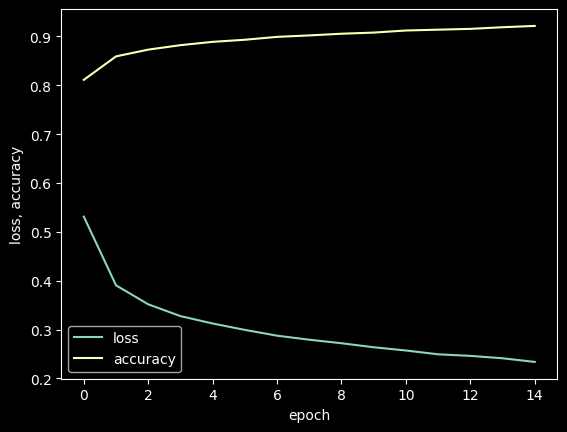

In [75]:
import matplotlib.pyplot as plt

plt.plot(categorical_model_history.history['loss'])
plt.plot(categorical_model_history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['loss', 'accuracy'])
plt.show()

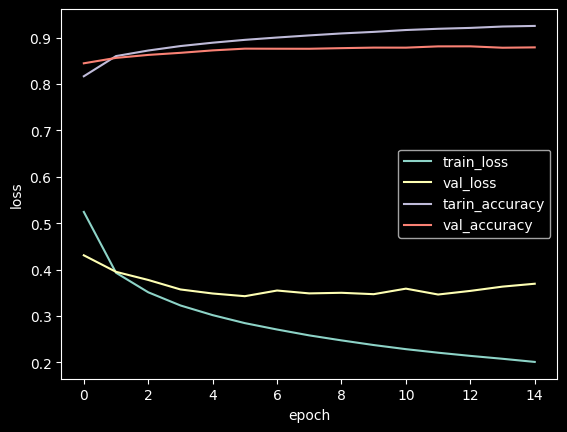

In [76]:
# 모델 생성
adam_model = create_model_for_categorical()

# 최적화 기법 선택
adamW = keras.optimizers.AdamW()
adam_model.compile(optimizer=adamW, loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 모델 훈련
categorical_model_adam_history = adam_model.fit(train_scaled, train_target, epochs=15, verbose=0,
                    validation_data=(val_scaled, val_target))

# 모델 훈련 과정 시각화
plt.plot(categorical_model_adam_history.history['loss'])
plt.plot(categorical_model_adam_history.history['val_loss'])
plt.plot(categorical_model_adam_history.history['accuracy'])
plt.plot(categorical_model_adam_history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss','tarin_accuracy', 'val_accuracy'])
plt.show()

In [77]:
def create_model_with_dropout():
    return keras.Sequential([
        keras.layers.Flatten(input_shape=(28, 28)),
        keras.layers.Dense(100, activation='relu'),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(10, activation='softmax')
    ])

dropout_model = create_model_with_dropout()

In [78]:
dropout_model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_22 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

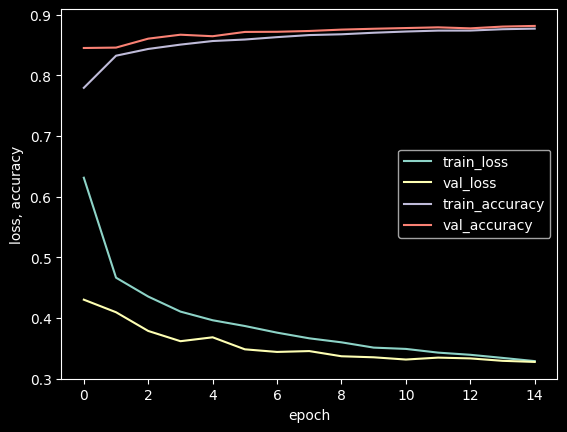

In [79]:
dropout_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

dropout_model_history = dropout_model.fit(train_scaled, train_target, epochs=15, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(dropout_model_history.history['loss'])
plt.plot(dropout_model_history.history['val_loss'])
plt.plot(dropout_model_history.history['accuracy'])
plt.plot(dropout_model_history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

In [80]:
import os

dropout_model.save('dropout-model.keras')
dropout_model.save_weights('dropout-model.weights.h5')

print('dropout-model.keras :', os.path.exists('dropout-model.keras'))
print('dropout-model.weights.h5 :', os.path.exists('dropout-model.weights.h5'))

dropout-model.keras : True
dropout-model.weights.h5 : True


In [81]:
loaded_dropout_model = keras.models.load_model('dropout-model.keras')
loaded_dropout_model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 998us/step - accuracy: 0.8817 - loss: 0.3274


[0.32742005586624146, 0.8817499876022339]

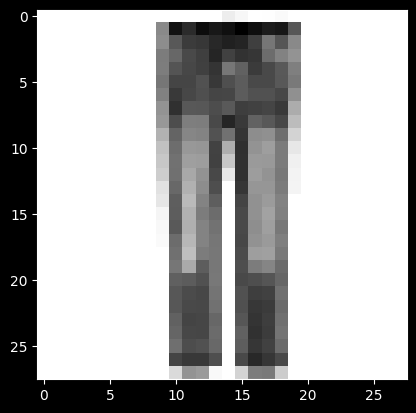

In [82]:
plt.imshow(test_scaled[15].reshape(28, 28), cmap='gray_r')
plt.show()